Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== 5 DÒNG ĐẦU ===
       ID Delivery_person_ID  Delivery_person_Age  Delivery_person_Ratings  \
0  0xcdcd      DEHRES17DEL01                 36.0                      4.2   
1  0xd987      KOCRES16DEL01                 21.0                      4.7   
2  0x2784     PUNERES13DEL03                 23.0                      4.7   
3  0xc8b6     LUDHRES15DEL02                 34.0                      4.3   
4  0xdb64      KNPRES14DEL02                 24.0                      4.7   

   Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0            30.327968             78.046106                   30.397968   
1            10.003064             76.307589                   10.043064   
2            18.562450             73.916619                   18.652450   
3            30.899584             75.809346                   30.919584   
4  

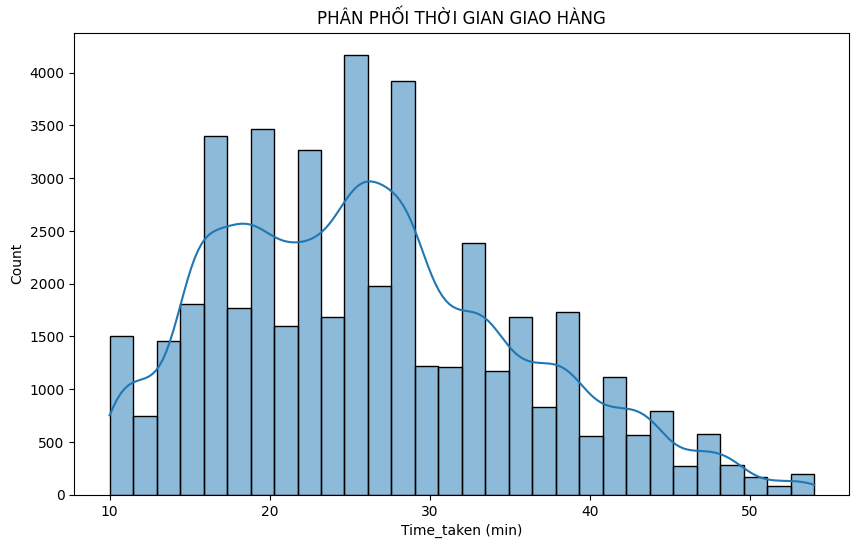


=== ĐÁNH GIÁ MODEL ===
MAE (Phút): 5.088049305365328
RMSE (Phút): 6.425376404741484


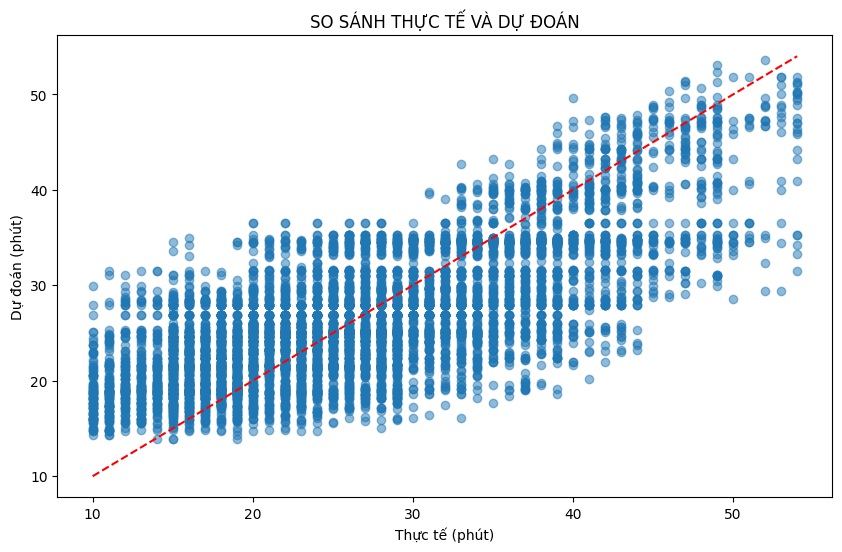


=== PIVOT TABLE (TRUNG BÌNH TIME_TAKEN) ===
Type_of_vehicle                          electric_scooter  motorcycle  \
Road_traffic_density Weather_conditions                                 
High                 Cloudy                     29.793103   28.475452   
                     Fog                        28.984375   28.018779   
                     Sandstorms                 24.190476   29.500000   
                     Stormy                     25.264151   29.978571   
                     Sunny                      17.607843   27.849515   
                     Windy                      24.396226   29.380353   
Jam                  Cloudy                     35.854430   37.125095   
                     Fog                        36.020202   37.576664   
                     Sandstorms                 26.568966   32.346843   
                     Stormy                     26.288043   32.482759   
                     Sunny                      20.052910   26.127076   
      

In [ ]:
# General Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

import warnings
import gspread
from google.colab import drive
from gspread_dataframe import set_with_dataframe
from google.colab import auth
from google.auth import default
from oauth2client.service_account import ServiceAccountCredentials
import pandas as pd

# Configs:
warnings.filterwarnings('ignore')
drive.mount('/content/drive')

# Google Authetication:
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Global constants
TIME_FMT = '%H:%M'
DATE_FMT = '%d-%m-%Y'
SEED = 359
# load data
df = pd.read_excel('/content/drive/My Drive/Colab Notebooks/Zomato Dataset.xlsx')

# Kiểm tra data gốc
print("=== 5 DÒNG ĐẦU ===")
print(df.head())

print("\n=== THỐNG KÊ TIME_TAKEN ===")
print(df['Time_taken (min)'].describe())

# Vẽ phân phối thời gian
plt.figure(figsize=(10, 6))
sns.histplot(df['Time_taken (min)'], bins=30, kde=True)
plt.title("PHÂN PHỐI THỜI GIAN GIAO HÀNG")
plt.show()

# ----------------------
# BƯỚC 3: TIỀN XỬ LÝ DATA
# ----------------------
# Xử lý missing values (nếu có)
df.dropna(inplace=True)

# Chia features (X) và target (y)
X = df[['Weather_conditions', 'Road_traffic_density', 'Type_of_vehicle',
        'Vehicle_condition', 'multiple_deliveries', 'Festival', 'City']]
y = df['Time_taken (min)']

# Chuyển categorical features thành số
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), ['Weather_conditions', 'Road_traffic_density',
                                'Type_of_vehicle', 'Festival', 'City'])
    ],
    remainder='passthrough'  # Giữ nguyên cột số
)

X_processed = preprocessor.fit_transform(X)

# ----------------------
# BƯỚC 4: CHIA DATA VÀ TRAIN MODEL
# ----------------------
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Sử dụng Random Forest (có thể điều chỉnh hyperparameter)
model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# ----------------------
# BƯỚC 5: ĐÁNH GIÁ MODEL
# ----------------------
y_pred = model.predict(X_test)

print("\n=== ĐÁNH GIÁ MODEL ===")
print("MAE (Phút):", mean_absolute_error(y_test, y_pred))
print("RMSE (Phút):", np.sqrt(mean_squared_error(y_test, y_pred)))

# Vẽ biểu đồ so sánh thực tế vs dự đoán
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Thực tế (phút)")
plt.ylabel("Dự đoán (phút)")
plt.title("SO SÁNH THỰC TẾ VÀ DỰ ĐOÁN")
plt.show()

# ----------------------
# BƯỚC 6: PHÂN TÍCH PIVOT TABLE
# ----------------------
# Tạo pivot table để kiểm tra
pivot_table = pd.pivot_table(
    df,
    values='Time_taken (min)',
    index=['Road_traffic_density', 'Weather_conditions'],
    columns=['Type_of_vehicle'],
    aggfunc=np.mean
)

print("\n=== PIVOT TABLE (TRUNG BÌNH TIME_TAKEN) ===")
print(pivot_table)

# ----------------------
# BƯỚC 7: DỰ ĐOÁN MỚI
# ----------------------
new_data = pd.DataFrame({
    'Weather_conditions': ['Fog'],
    'Road_traffic_density': ['Jam'],
    'Type_of_vehicle': ['motorcycle'],
    'Vehicle_condition': [2],
    'multiple_deliveries': [3.0],
    'Festival': ['No'],
    'City': ['Metropolitian']
})

new_processed = preprocessor.transform(new_data)
predicted_time = model.predict(new_processed)
print("\n=== DỰ ĐOÁN ===")
print("Thời gian giao hàng ước tính (phút):", predicted_time[0])

In [ ]:
# Lấy số cột one-hot (số feature do OneHotEncoder tạo ra)
n_ohe_features = preprocessor.named_transformers_['cat'].transform(
    pd.DataFrame([['Sunny', 'Low', 'motorcycle', 'No', 'Urban']],
                 columns=['Weather_conditions', 'Road_traffic_density', 'Type_of_vehicle', 'Festival', 'City'])
).shape[1]

# 👉 Tách X_test thành one-hot + numeric
X_test_ohe = X_test[:, :n_ohe_features]
X_test_num = X_test[:, n_ohe_features:]

# 👉 inverse_transform phần one-hot
X_test_labels = ohe.inverse_transform(X_test_ohe)

# 👉 Chuyển thành DataFrame
X_test_labels_df = pd.DataFrame(X_test_labels, columns=ohe.feature_names_in_)

# 👉 Tạo DataFrame numeric
numeric_columns = ['Vehicle_condition', 'multiple_deliveries']
X_test_numeric_df = pd.DataFrame(X_test_num, columns=numeric_columns)

# 👉 Gộp lại
X_test_final = pd.concat([X_test_labels_df.reset_index(drop=True), X_test_numeric_df.reset_index(drop=True)], axis=1)

# 👉 Kết quả dự đoán
results_df = pd.DataFrame({
    'Actual Time (min)': y_test.values,
    'Predicted Time (min)': y_pred
})

# 👉 Kết hợp kết quả + feature gốc
final_df = pd.concat([results_df.reset_index(drop=True), X_test_final.reset_index(drop=True)], axis=1)

# ----------------------------
# Xuất lên Google Sheet
spreadsheet = gc.create("RandomForest_Result")
worksheet = spreadsheet.sheet1

set_with_dataframe(worksheet, final_df)

print("✅ Data written to Google Sheet:")
print(spreadsheet.url)

✅ Data written to Google Sheet:
https://docs.google.com/spreadsheets/d/1dlsD25xWB0JeAF8YDBBjtOL79w9M5L029bIeApzyMBQ


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/My Drive')

['The_Development_of_Performance_Dashboard.pdf',
 'The_Development_of_Performance_Dashboard.gdoc',
 'Bản dịch của The_Development_of_Performance_Dashboard.gdoc',
 'Dũng_BTCN',
 'Microsoft Power BI.gdoc',
 'Case03-Remarkable turnaround.pdf',
 'Case03-Remarkable turnaround.gdoc',
 'Bản dịch của Case03-Remarkable turnaround.gdoc',
 'Trần Tiến Dũng_2470066_BT3.1.drawio',
 'Trần Tiến Dũng_2470066_BT3.2.drawio',
 'TranTien Dung_2470066_BT3.22 (4).drawio',
 'BT1.drawio',
 'bpmn_process.drawio',
 'Colab Notebooks',
 'BT 9.3 & 9.5.gdoc',
 'Project B.drawio',
 '2470066.drawio',
 'BT NHÓM: QUẢN LÝ VÀ LÃNH ĐẠO.gdoc']

In [ ]:
import os

os.path.exists('/content/drive/My Drive/Colab Notebooks/Zomato Dataset.xlsx')

True